# 13 — Multi-Condition Bias Mitigation Experiment

**Context:** Notebook 11 showed all tested LLMs exhibit a systematic pro-climate bias
(+0.73 to +1.50 mean error). Notebook 12 tested third-person perspective shift — **no effect**.

**This notebook** tests four conditions combining two remaining interventions:
- **Two-step reasoning** — force explicit reasoning about factors shaping the persona's view before committing to a letter
- **Numeric scale** — replace A-G letters with -3 to +3 numbers (negative numbers carry evaluative signal)

**Conditions:**

| Condition | Reasoning | Scale | Anti-sycophancy | Scale randomisation |
|---|---|---|---|---|
| **A (control)** | Single-step | A-G letters | No | No |
| **B** | Two-step | A-G letters | Yes | No |
| **C** | Single-step | -3 to +3 numeric | No | 50% reversed |
| **D (combined)** | Two-step | -3 to +3 numeric | Yes | 50% reversed |

**Design:** Same N agents × M models as notebooks 11-12. ~360 API calls total.

**References:**
- Chain-of-thought prompting (Wei et al. 2022)
- Anti-sycophancy instructions (ELEPHANT, Cheng et al. 2025)
- Primacy/recency effects in LLM scale selection (Eicher & Irgolič 2024, arXiv:2402.01740)

In [ ]:
# ── Imports ──
import sys, os, logging, time, random, re, json
import pandas as pd
import numpy as np
from datetime import date, datetime
from statistics import mean, stdev
from collections import Counter
from scipy.stats import spearmanr, wilcoxon

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

from cag.io.survey import load
from cag.io.llm import load_api_key, send_chat, parse_letter_response
from cag.abm.agent import SurveyedCitizen
from cag.abm.environment import SurveyedNation
from cag.abm.attributes.opinion import (
    ClimatePolicyID, SURVEY_COLUMN_MAP, SURVEY_QUESTIONS,
    RESPONSE_SCALE, RESPONSE_LABELS, ordinal_score,
)

from gabm.abm.attributes.gender import GenderMap, GenderID
from gabm.abm.attributes.politics import PoliticsID
from gabm.abm.democracy.election import ElectionID
from cag.abm.attributes.region import UKRegionMap, RegionID
from cag.abm.attributes.education import SurveyEducationMap, EducationID
from cag.abm.attributes.ethnicity import SurveyEthnicityMap, EthnicityID
from cag.abm.attributes.income import SurveyIncomeMap, IncomeID
from cag.abm.attributes.politics import SurveyPoliticsMap
from cag.abm.attributes.family import SurveyFamilyMap, FamilyID
from cag.abm.democracy.elections.ukge2019 import UKGE2019VoteMap, UKGE2019VoteID
from cag.abm.democracy.elections.brexit import BrexitVoteMap, BrexitVoteID
from cag.abm.attributes.narratives import (
    SelftranscMap, SelfenhMap, OpennessMap, ConformTradMap, SDOMap, EDOMap, RWAMap,
    rescale_1_6, rescale_1_7,
)

logging.basicConfig(level=logging.WARNING)
print("Imports OK")

## Configuration

Two models selected based on notebook 11 results:
- **gemini-3.1-pro** — lowest signed error (+0.73) from notebook 11
- **claude-sonnet-4-6** — best MAE (1.80), best Spearman ρ (0.437) from notebook 11

Total API calls: 2 models × 4 conditions × 30 agents × (1 or 2 calls) ≈ **360 calls**.

In [9]:
# ── Experiment config ──
MODELS = [
    ("gemini-3.1-pro",     "gemini-3.1-pro-preview",  "genai"),
    ("claude-sonnet-4-6",  "claude-sonnet-4-6",       "anthropic"),
]

CONDITIONS = ["A", "B", "C", "D"]

POLICY_ID = ClimatePolicyID.BAN_PETROL_CARS
N_AGENTS = 30
TEMPERATURE = 0.5
THINKING = True
RANDOM_SEED = 44  # same seed as notebooks 11-12 for comparability

# Load API keys
api_keys = {}
for _, _, provider in MODELS:
    if provider not in api_keys:
        api_keys[provider] = load_api_key(provider)

print(f"Policy: {POLICY_ID}")
print(f"Agents: {N_AGENTS}, Seed: {RANDOM_SEED}, Temperature: {TEMPERATURE}, Thinking: {THINKING}")
print(f"Models: {[name for name, _, _ in MODELS]}")
print(f"Conditions: {CONDITIONS}")
print(f"API keys loaded for: {list(api_keys.keys())}")

Policy: ClimatePolicyID(3)
Agents: 30, Seed: 44, Temperature: 0.5, Thinking: True
Models: ['gemini-3.1-pro', 'claude-sonnet-4-6']
Conditions: ['A', 'B', 'C', 'D']
API keys loaded for: ['genai', 'anthropic']


## Build environment and sample agents

In [10]:
# ── Build the SurveyedNation and sample agents ──
random.seed(RANDOM_SEED)
year = 2026

UKGE2019_ELECTION_ID = ElectionID(0)
BREXIT_REFERENDUM_ID = ElectionID(1)

sn = SurveyedNation(
    year=year, place="UK",
    gender_map=GenderMap(),
    region_map=UKRegionMap(),
    education_map=SurveyEducationMap(),
    ethnicity_map=SurveyEthnicityMap(),
    income_map=SurveyIncomeMap(),
    politics_map=SurveyPoliticsMap(),
    family_map=SurveyFamilyMap(),
    ukge2019_vote_map=UKGE2019VoteMap(UKGE2019_ELECTION_ID),
    brexit_vote_map=BrexitVoteMap(BREXIT_REFERENDUM_ID),
    selftransc_map=SelftranscMap,
    selfenh_map=SelfenhMap,
    openness_map=OpennessMap,
    conformtrad_map=ConformTradMap,
    sdo_map=SDOMap,
    edo_map=EDOMap,
    rwa_map=RWAMap,
)

data = load("../data/yougov_survey_data/YouGovProcessedData.csv")
data = data.sample(n=N_AGENTS, random_state=RANDOM_SEED)

for i in range(len(data)):
    row = data.iloc[i]
    sc = SurveyedCitizen(
        agent_id=row.get('ID', None), environment=sn,
        year_of_birth=year - int(row.get('age', 0)),
        gender_id=GenderID.MALE if int(row.get('male_dummy', 0)) == 1 else GenderID.FEMALE,
        region_id=RegionID(int(row.get('tprofile_GOR', 0))),
        education_id=EducationID(int(row.get('profile_education_level', 0))),
        income_id=IncomeID(int(row.get('tprofile_gross_household', 0))),
        ethnicity_id=EthnicityID(int(row.get('ethnicity_R', 0))),
        family_id=FamilyID.PARENT if int(row.get('parent_dummy', 0)) == 1 else FamilyID.NOT_PARENT,
        ukge2019_vote_id=UKGE2019VoteID(int(row.get('Vote2019R', 0))),
        brexit_vote_id=BrexitVoteID(int(row.get('pastvote_EURef', 0))),
        politics_id=PoliticsID(int(row.get('Political_Left_Right', 0))),
        selftransc_id=rescale_1_6(int(row.get('Selftransc_Val', 0))),
        selfenh_id=rescale_1_6(int(row.get('Selfenh_Values', 0))),
        openness_id=rescale_1_6(int(row.get('Openness', 0))),
        conformtrad_id=rescale_1_6(int(row.get('ConformTrad', 0))),
        sdo_id=rescale_1_7(int(row.get('SDO', 0))),
        edo_id=rescale_1_7(int(row.get('EDO', 0))),
        rwa_id=rescale_1_6(int(row.get('RWA', 0))),
        original_survey_data=data.iloc[i],
    )
    sn.agents_active[sc.id] = sc

agents = list(sn.agents_active.values())
print(f"Sampled {len(agents)} agents")

# Ground truth for each agent
ground_truth = {}
for agent in agents:
    ground_truth[agent.id] = agent.get_real_survey_response(POLICY_ID)

gt_values = list(ground_truth.values())
print(f"Ground truth mean: {mean(gt_values):+.3f}, SD: {stdev(gt_values):.3f}")
print(f"Distribution: {dict(sorted(Counter(gt_values).items()))}")

Sampled 30 agents
Ground truth mean: +0.067, SD: 2.132
Distribution: {-3: 6, -2: 2, -1: 3, 0: 7, 1: 2, 2: 5, 3: 5}


## Prompt construction

Four conditions, each with its own system prompt builder and run strategy:

| Condition | System prompt | User prompt | LLM calls | Parse |
|---|---|---|---|---|
| **A (control)** | Standard 1P persona | Standard A-G | 1 | `parse_letter_response()` |
| **B (two-step)** | Standard 1P persona | Step 1: reasoning with anti-sycophancy. Step 2: A-G with reasoning context | 2 | `parse_letter_response()` |
| **C (numeric)** | Standard 1P persona | -3 to +3 numeric scale (50% reversed) | 1 | `parse_numeric_response()` |
| **D (combined)** | Standard 1P persona | Step 1: reasoning with anti-sycophancy. Step 2: numeric with reasoning context (50% reversed) | 2 | `parse_numeric_response()` |

In [11]:
# ── Prompt builders and response parsers ──

# ── Numeric response parser ──

def parse_numeric_response(response):
    """Extract a single integer -3 to +3 from a free-text LLM response.

    Returns
    -------
    int
        A value in {-3, -2, -1, 0, 1, 2, 3}.

    Raises
    ------
    ValueError
        If no valid number can be extracted.
    """
    text = response.strip()
    if not text:
        raise ValueError("Empty response — cannot extract a number.")

    # Strip markdown bold/italic formatting (e.g. **-2**, *+1*)
    text = re.sub(r'\*+', '', text)

    # 1. Try to find patterns like "answer is -2", "response: +1", "I choose 0"
    match = re.search(
        r'(?:answer|response|choice|choose|select|rating|score)\s*(?:is|:)?\s*([+-]?[0-3])',
        text, re.IGNORECASE
    )
    if match:
        val = int(match.group(1))
        if -3 <= val <= 3:
            return val

    # 2. First line / first token: check if it's just a number
    first_line = text.split('\n')[0].strip()
    match = re.match(r'^([+-]?[0-3])(?:[.,;:\s)]|$)', first_line)
    if match:
        val = int(match.group(1))
        if -3 <= val <= 3:
            return val

    # 3. Any standalone number -3 to +3 in the text
    matches = re.findall(r'(?:^|\s)([+-]?[0-3])(?:\s|[.,;:)]|$)', text)
    valid = [int(m) for m in matches if -3 <= int(m) <= 3]
    if valid:
        return valid[0]

    raise ValueError(f"Cannot extract a number -3 to +3 from: {text[:200]}")


# ── Scale builders ──

NUMERIC_SCALE_NORMAL = {
    -3: "Strongly oppose",
    -2: "Somewhat oppose",
    -1: "Slightly oppose",
     0: "Neutral",
    +1: "Slightly support",
    +2: "Somewhat support",
    +3: "Strongly support",
}

NUMERIC_SCALE_REVERSED = {
    +3: "Strongly support",
    +2: "Somewhat support",
    +1: "Slightly support",
     0: "Neutral",
    -1: "Slightly oppose",
    -2: "Somewhat oppose",
    -3: "Strongly oppose",
}


def _format_numeric_scale(reversed_order=False):
    """Format the numeric scale as a string for the prompt."""
    scale = NUMERIC_SCALE_REVERSED if reversed_order else NUMERIC_SCALE_NORMAL
    return "\n".join(f"{k:+d} = {v}" for k, v in scale.items())


# ── Anti-sycophancy preamble ──

ANTI_SYCOPHANCY = (
    "Your task is to faithfully simulate how this specific person would respond, "
    "NOT to give the 'correct' or socially desirable answer. "
    "Real people with this profile hold a WIDE range of views on climate policy, "
    "including strong opposition. That is expected and acceptable."
)


# ── Condition A: Control (standard 1P baseline) ──

def run_condition_A(agent, policy_id, api_key, model_id, provider):
    """Single-step, letter scale. Identical to notebooks 11-12 control."""
    system_prompt = agent.get_system_prompt(day=0)
    policy_question = SURVEY_QUESTIONS[policy_id]
    response_options = "\n".join(f"{letter}. {label}" for letter, label in RESPONSE_LABELS.items())
    user_prompt = policy_question + "\n\n" + response_options + "\n\nRespond with a single letter A-G."

    llm_response = send_chat(
        system_prompt, user_prompt,
        api_key=api_key, model=model_id,
        provider=provider, temperature=TEMPERATURE, thinking=THINKING,
    )
    letter = parse_letter_response(llm_response)
    numeric = RESPONSE_SCALE[letter]
    return numeric, {"step1_reasoning": None, "reversed": False, "raw_response": llm_response}


# ── Condition B: Two-step reasoning + anti-sycophancy, letter scale ──

STEP1_TEMPLATE = (
    "{anti_sycophancy}\n\n"
    "Given this person's demographic profile, political history, and psychological values, "
    "what factors would shape their view on the following policy?\n\n"
    "{policy_question}\n\n"
    "Consider factors that might lead them to SUPPORT this policy AND factors that might "
    "lead them to OPPOSE it. Think about their voting history, their values, their life "
    "circumstances, and how these might interact.\n\n"
    "Provide your reasoning in 2-3 sentences."
)

STEP2_LETTER_TEMPLATE = (
    "Based on the reasoning above, how would this person respond to the following survey question?\n\n"
    "{policy_question}\n\n"
    "{response_options}\n\n"
    "Respond with a single letter A-G."
)


def run_condition_B(agent, policy_id, api_key, model_id, provider):
    """Two-step reasoning with anti-sycophancy, letter scale."""
    system_prompt = agent.get_system_prompt(day=0)
    policy_question = SURVEY_QUESTIONS[policy_id]

    # Step 1: Elicit reasoning
    step1_prompt = STEP1_TEMPLATE.format(
        anti_sycophancy=ANTI_SYCOPHANCY,
        policy_question=policy_question,
    )
    reasoning = send_chat(
        system_prompt, step1_prompt,
        api_key=api_key, model=model_id,
        provider=provider, temperature=TEMPERATURE, thinking=THINKING,
    )

    # Step 2: Get answer with reasoning context
    response_options = "\n".join(f"{letter}. {label}" for letter, label in RESPONSE_LABELS.items())
    step2_system = system_prompt + "\n\nYour reasoning about this policy:\n" + reasoning
    step2_prompt = STEP2_LETTER_TEMPLATE.format(
        policy_question=policy_question,
        response_options=response_options,
    )
    llm_response = send_chat(
        step2_system, step2_prompt,
        api_key=api_key, model=model_id,
        provider=provider, temperature=TEMPERATURE, thinking=THINKING,
    )
    letter = parse_letter_response(llm_response)
    numeric = RESPONSE_SCALE[letter]
    return numeric, {"step1_reasoning": reasoning, "reversed": False, "raw_response": llm_response}


# ── Condition C: Numeric scale with 50% reversal ──

def run_condition_C(agent, policy_id, api_key, model_id, provider, agent_index=0):
    """Single-step, numeric scale. 50% of agents get reversed scale order."""
    system_prompt = agent.get_system_prompt(day=0)
    policy_question = SURVEY_QUESTIONS[policy_id]
    reversed_order = (agent_index % 2 == 1)  # odd-indexed agents get reversed scale
    scale_str = _format_numeric_scale(reversed_order)

    user_prompt = (
        policy_question + "\n\n"
        "Rate your position on the following scale:\n"
        + scale_str + "\n\n"
        "Respond with a single number from -3 to +3."
    )

    llm_response = send_chat(
        system_prompt, user_prompt,
        api_key=api_key, model=model_id,
        provider=provider, temperature=TEMPERATURE, thinking=THINKING,
    )
    numeric = parse_numeric_response(llm_response)
    return numeric, {"step1_reasoning": None, "reversed": reversed_order, "raw_response": llm_response}


# ── Condition D: Combined (two-step reasoning + numeric scale) ──

STEP2_NUMERIC_TEMPLATE = (
    "Based on the reasoning above, how would this person respond to the following survey question?\n\n"
    "{policy_question}\n\n"
    "Rate your position on the following scale:\n"
    "{scale_str}\n\n"
    "Respond with a single number from -3 to +3."
)


def run_condition_D(agent, policy_id, api_key, model_id, provider, agent_index=0):
    """Two-step reasoning with anti-sycophancy, numeric scale with reversal."""
    system_prompt = agent.get_system_prompt(day=0)
    policy_question = SURVEY_QUESTIONS[policy_id]
    reversed_order = (agent_index % 2 == 1)

    # Step 1: Elicit reasoning (same as condition B)
    step1_prompt = STEP1_TEMPLATE.format(
        anti_sycophancy=ANTI_SYCOPHANCY,
        policy_question=policy_question,
    )
    reasoning = send_chat(
        system_prompt, step1_prompt,
        api_key=api_key, model=model_id,
        provider=provider, temperature=TEMPERATURE, thinking=THINKING,
    )

    # Step 2: Get numeric answer with reasoning context
    scale_str = _format_numeric_scale(reversed_order)
    step2_system = system_prompt + "\n\nYour reasoning about this policy:\n" + reasoning
    step2_prompt = STEP2_NUMERIC_TEMPLATE.format(
        policy_question=policy_question,
        scale_str=scale_str,
    )
    llm_response = send_chat(
        step2_system, step2_prompt,
        api_key=api_key, model=model_id,
        provider=provider, temperature=TEMPERATURE, thinking=THINKING,
    )
    numeric = parse_numeric_response(llm_response)
    return numeric, {"step1_reasoning": reasoning, "reversed": reversed_order, "raw_response": llm_response}


# ── Condition dispatcher ──

CONDITION_RUNNERS = {
    "A": run_condition_A,
    "B": run_condition_B,
    "C": run_condition_C,
    "D": run_condition_D,
}

print("Prompt builders and condition runners defined.")
print(f"  A: single-step, A-G letter scale (control)")
print(f"  B: two-step reasoning + anti-sycophancy, A-G letter scale")
print(f"  C: single-step, numeric -3 to +3 (50% reversed)")
print(f"  D: two-step reasoning + anti-sycophancy, numeric -3 to +3 (50% reversed)")

Prompt builders and condition runners defined.
  A: single-step, A-G letter scale (control)
  B: two-step reasoning + anti-sycophancy, A-G letter scale
  C: single-step, numeric -3 to +3 (50% reversed)
  D: two-step reasoning + anti-sycophancy, numeric -3 to +3 (50% reversed)


## Preview prompts for one agent

Verify the four conditions produce sensible prompts before running the full experiment.

In [12]:
# ── Preview: show prompts for each condition ──
preview_agent = agents[0]
policy_question = SURVEY_QUESTIONS[POLICY_ID]

print("=" * 70)
print("CONDITION A (control): Standard 1P + letter scale")
print("=" * 70)
sys_a = preview_agent.get_system_prompt(day=0)
usr_a = policy_question + "\n\n" + "\n".join(f"{l}. {lb}" for l, lb in RESPONSE_LABELS.items()) + "\n\nRespond with a single letter A-G."
print("[SYSTEM]\n" + sys_a[:300] + "...")
print("\n[USER]\n" + usr_a)

print("\n" + "=" * 70)
print("CONDITION B: Two-step reasoning + anti-sycophancy + letter scale")
print("=" * 70)
step1 = STEP1_TEMPLATE.format(anti_sycophancy=ANTI_SYCOPHANCY, policy_question=policy_question)
response_options = "\n".join(f"{l}. {lb}" for l, lb in RESPONSE_LABELS.items())
step2 = STEP2_LETTER_TEMPLATE.format(policy_question=policy_question, response_options=response_options)
print("[STEP 1 USER]\n" + step1)
print("\n[STEP 2 USER]\n" + step2)

print("\n" + "=" * 70)
print("CONDITION C: Numeric scale (normal order for even-index agent)")
print("=" * 70)
scale_normal = _format_numeric_scale(reversed_order=False)
usr_c = policy_question + "\n\nRate your position on the following scale:\n" + scale_normal + "\n\nRespond with a single number from -3 to +3."
print("[USER]\n" + usr_c)

print("\n" + "=" * 70)
print("CONDITION C: Numeric scale (REVERSED order for odd-index agent)")
print("=" * 70)
scale_rev = _format_numeric_scale(reversed_order=True)
usr_c_rev = policy_question + "\n\nRate your position on the following scale:\n" + scale_rev + "\n\nRespond with a single number from -3 to +3."
print("[USER]\n" + usr_c_rev)

print("\n" + "=" * 70)
print("CONDITION D: Two-step + numeric (same step 1 as B, numeric step 2)")
print("=" * 70)
step2_d = STEP2_NUMERIC_TEMPLATE.format(policy_question=policy_question, scale_str=scale_normal)
print("[STEP 2 USER]\n" + step2_d)

print(f"\nAgent {preview_agent.id}: ground truth = {ground_truth[preview_agent.id]:+d}")

CONDITION A (control): Standard 1P + letter scale
[SYSTEM]
I am a 27 year old female living in the Wales. My ethnicity is white. I have a University or CNAA higher degree (e.g. M.Sc, Ph.D). My gross household income is £20,000 - £24,999 per year. I am not a parent. I position myself fairly left-wing of the political spectrum. I voted for the Green party can...

[USER]
Please say how much you support or oppose government policies that do the following: Ban the sale of new petrol cars by no later than 2030

A. Strongly oppose
B. Somewhat oppose
C. Slightly oppose
D. Neutral
E. Slightly support
F. Somewhat support
G. Strongly support

Respond with a single letter A-G.

CONDITION B: Two-step reasoning + anti-sycophancy + letter scale
[STEP 1 USER]
Your task is to faithfully simulate how this specific person would respond, NOT to give the 'correct' or socially desirable answer. Real people with this profile hold a WIDE range of views on climate policy, including strong opposition. That is e

## Run experiment

For each model × condition × agent, call the appropriate condition runner.
Conditions B and D use 2 API calls per agent (reasoning + answer).

**Cost estimate:** ~360 API calls (2 models × 4 conditions × 30 agents × 1-2 calls).

In [13]:
# ── Run 4-condition experiment ──
all_results = []

for model_name, model_id, provider in MODELS:
    api_key = api_keys[provider]

    for condition in CONDITIONS:
        print(f"\n{'='*60}")
        print(f"{model_name} — Condition {condition}")
        print(f"{'='*60}")

        runner = CONDITION_RUNNERS[condition]
        t0 = time.time()

        for i, agent in enumerate(agents):
            try:
                # Conditions C and D need agent_index for scale reversal
                if condition in ("C", "D"):
                    numeric, meta = runner(
                        agent, POLICY_ID, api_key, model_id, provider,
                        agent_index=i,
                    )
                else:
                    numeric, meta = runner(
                        agent, POLICY_ID, api_key, model_id, provider,
                    )

                real = ground_truth[agent.id]

                all_results.append({
                    "model": model_name,
                    "condition": condition,
                    "agent_id": agent.id,
                    "llm_numeric": numeric,
                    "real_numeric": real,
                    "error": numeric - real,
                    "abs_error": abs(numeric - real),
                    "exact_match": int(numeric == real),
                    "ordinal_score": ordinal_score(numeric, real),
                    "step1_reasoning": meta.get("step1_reasoning"),
                    "reversed_scale": meta.get("reversed", False),
                })

                if (i + 1) % 10 == 0:
                    print(f"  {i+1}/{len(agents)} agents done")

            except Exception as e:
                print(f"  ERROR agent {agent.id}: {e}")
                all_results.append({
                    "model": model_name,
                    "condition": condition,
                    "agent_id": agent.id,
                    "llm_numeric": None,
                    "real_numeric": ground_truth[agent.id],
                    "error": None,
                    "abs_error": None,
                    "exact_match": 0,
                    "ordinal_score": None,
                    "step1_reasoning": None,
                    "reversed_scale": False,
                })

        elapsed = time.time() - t0
        print(f"  Done in {elapsed:.1f}s")

df = pd.DataFrame(all_results)
n_success = len(df[df['llm_numeric'].notna()])
print(f"\nTotal results: {len(df)} ({n_success} successful)")


gemini-3.1-pro — Condition A
  10/30 agents done
  20/30 agents done
  30/30 agents done
  Done in 232.5s

gemini-3.1-pro — Condition B
  10/30 agents done
  20/30 agents done
  30/30 agents done
  Done in 515.0s

gemini-3.1-pro — Condition C
  ERROR agent 1334.0: Google GenAI API call failed: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_requests_per_model_per_day, limit: 250, model: gemini-3.1-pro\nPlease retry in 57m23.356006086s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': '

## Metrics per model × condition

| Metric | Description |
|---|---|
| **Exact %** | LLM == real survey response |
| **Ordinal** | 1 − (distance / max_distance), averaged |
| **Mean Error** | Average (LLM − real). Positive = pro-climate bias |
| **MAE** | Mean absolute error |
| **Direction %** | Correct side: oppose/neutral/support |
| **Spearman ρ** | Rank correlation between LLM and real |

In [14]:
# ── Compute metrics per (model, condition) ──
def direction(v):
    if v < 0: return -1
    elif v > 0: return 1
    else: return 0

summary_rows = []
for (model_name, condition), grp in df.groupby(["model", "condition"]):
    mdf = grp[grp["llm_numeric"].notna()].copy()
    n = len(mdf)
    if n == 0:
        continue

    exact_acc = mdf["exact_match"].mean()
    ord_score = mdf["ordinal_score"].mean()
    mean_err = mdf["error"].mean()
    mae = mdf["abs_error"].mean()

    mdf["llm_dir"] = mdf["llm_numeric"].apply(direction)
    mdf["real_dir"] = mdf["real_numeric"].apply(direction)
    dir_acc = (mdf["llm_dir"] == mdf["real_dir"]).mean()

    if mdf["llm_numeric"].nunique() > 1 and mdf["real_numeric"].nunique() > 1:
        rho, p_val = spearmanr(mdf["llm_numeric"], mdf["real_numeric"])
    else:
        rho, p_val = float('nan'), float('nan')

    mean_llm = mdf["llm_numeric"].mean()

    summary_rows.append({
        "Model": model_name,
        "Condition": condition,
        "n": n,
        "Mean LLM": mean_llm,
        "Exact %": exact_acc,
        "Ordinal": ord_score,
        "Mean Error": mean_err,
        "MAE": mae,
        "Direction %": dir_acc,
        "Spearman \u03c1": rho,
        "Spearman p": p_val,
    })

summary = pd.DataFrame(summary_rows)
gt_mean = mean(gt_values)
print(f"Ground truth mean: {gt_mean:+.3f}")
print()

display_cols = ["Model", "Condition", "n", "Mean LLM", "Exact %", "Ordinal",
                "Mean Error", "MAE", "Direction %", "Spearman \u03c1"]
styled = summary[display_cols].style.format({
    "Mean LLM": "{:+.3f}",
    "Exact %": "{:.1%}",
    "Ordinal": "{:.3f}",
    "Mean Error": "{:+.3f}",
    "MAE": "{:.3f}",
    "Direction %": "{:.1%}",
    "Spearman \u03c1": "{:.3f}",
})
styled

Ground truth mean: +0.067



,Model,Condition,n,Mean LLM,Exact %,Ordinal,Mean Error,MAE,Direction %,Spearman ρ
0,claude-sonnet-4-6,A,30,+1.133,20.0%,0.689,+1.067,1.867,50.0%,0.417
1,claude-sonnet-4-6,B,30,+0.300,16.7%,0.694,+0.233,1.833,53.3%,0.424
2,claude-sonnet-4-6,C,30,+0.767,20.0%,0.717,+0.700,1.700,53.3%,0.392
3,claude-sonnet-4-6,D,30,+0.100,13.3%,0.706,+0.033,1.767,53.3%,0.385
4,gemini-3.1-pro,A,30,+0.833,26.7%,0.661,+0.767,2.033,43.3%,0.376
5,gemini-3.1-pro,B,30,-0.067,23.3%,0.689,-0.133,1.867,46.7%,0.377
6,gemini-3.1-pro,C,12,+1.500,41.7%,0.736,+1.083,1.583,58.3%,0.368


## Paired comparison: each condition vs control (A)

For each model, compare B, C, D against the A (control) baseline using
Wilcoxon signed-rank test on per-agent absolute errors.

In [15]:
# ── Paired statistical comparison: B/C/D vs A ──
print(f"{'Model':<22} {'Comparison':>12} {'\u0394 Mean Err':>11} {'\u0394 MAE':>8} {'\u0394 Spearman':>11}  {'Wilcoxon p':>10}  Interpretation")
print("-" * 100)

for model_name in summary["Model"].unique():
    s_ctrl = summary[(summary["Model"] == model_name) & (summary["Condition"] == "A")]
    if s_ctrl.empty:
        continue

    for cond in ["B", "C", "D"]:
        s_test = summary[(summary["Model"] == model_name) & (summary["Condition"] == cond)]
        if s_test.empty:
            continue

        d_err = s_test["Mean Error"].values[0] - s_ctrl["Mean Error"].values[0]
        d_mae = s_test["MAE"].values[0] - s_ctrl["MAE"].values[0]
        d_rho = s_test["Spearman \u03c1"].values[0] - s_ctrl["Spearman \u03c1"].values[0]

        # Paired Wilcoxon on absolute errors
        df_ctrl = df[(df["model"] == model_name) & (df["condition"] == "A") & df["abs_error"].notna()]
        df_test = df[(df["model"] == model_name) & (df["condition"] == cond) & df["abs_error"].notna()]

        paired = df_ctrl[["agent_id", "abs_error"]].merge(
            df_test[["agent_id", "abs_error"]], on="agent_id", suffixes=("_ctrl", "_test")
        )
        diffs = paired["abs_error_ctrl"] - paired["abs_error_test"]

        n_better = (diffs > 0).sum()
        n_worse = (diffs < 0).sum()
        n_same = (diffs == 0).sum()

        if (diffs != 0).sum() >= 1:
            try:
                stat, pv = wilcoxon(diffs[diffs != 0])
            except ValueError:
                pv = float('nan')
        else:
            pv = float('nan')

        if np.isnan(pv):
            interp = f"n/a ({n_better}\u2191 {n_worse}\u2193 {n_same}\u2194)"
        elif pv < 0.05 and d_mae < 0:
            interp = f"{cond} significantly better ({n_better}\u2191 {n_worse}\u2193 {n_same}\u2194)"
        elif pv < 0.05 and d_mae > 0:
            interp = f"A significantly better ({n_better}\u2191 {n_worse}\u2193 {n_same}\u2194)"
        elif pv < 0.10 and d_mae < 0:
            interp = f"{cond} marginally better ({n_better}\u2191 {n_worse}\u2193 {n_same}\u2194)"
        else:
            interp = f"no sig. diff. ({n_better}\u2191 {n_worse}\u2193 {n_same}\u2194)"

        print(f"{model_name:<22} {'A vs '+cond:>12} {d_err:>+10.3f}  {d_mae:>+7.3f}  {d_rho:>+10.3f}   {pv:>10.4f}  {interp}")

    print()  # blank line between models

print("\u0394 Mean Error < 0 \u2192 treatment has less pro-climate bias")
print("\u0394 MAE < 0 \u2192 treatment is more accurate")
print("\u0394 Spearman > 0 \u2192 treatment preserves ranking better")

Model                    Comparison  Δ Mean Err    Δ MAE  Δ Spearman  Wilcoxon p  Interpretation
----------------------------------------------------------------------------------------------------
claude-sonnet-4-6            A vs B     -0.833   -0.033      +0.007       0.9517  no sig. diff. (6↑ 7↓ 17↔)
claude-sonnet-4-6            A vs C     -0.367   -0.167      -0.025       0.2253  no sig. diff. (11↑ 6↓ 13↔)
claude-sonnet-4-6            A vs D     -1.033   -0.100      -0.032       0.6845  no sig. diff. (9↑ 9↓ 12↔)

gemini-3.1-pro               A vs B     -0.900   -0.167      +0.001       0.3476  no sig. diff. (11↑ 6↓ 13↔)
gemini-3.1-pro               A vs C     +0.317   -0.450      -0.009       0.2500  no sig. diff. (3↑ 0↓ 9↔)

Δ Mean Error < 0 → treatment has less pro-climate bias
Δ MAE < 0 → treatment is more accurate
Δ Spearman > 0 → treatment preserves ranking better


## Error distribution heatmap

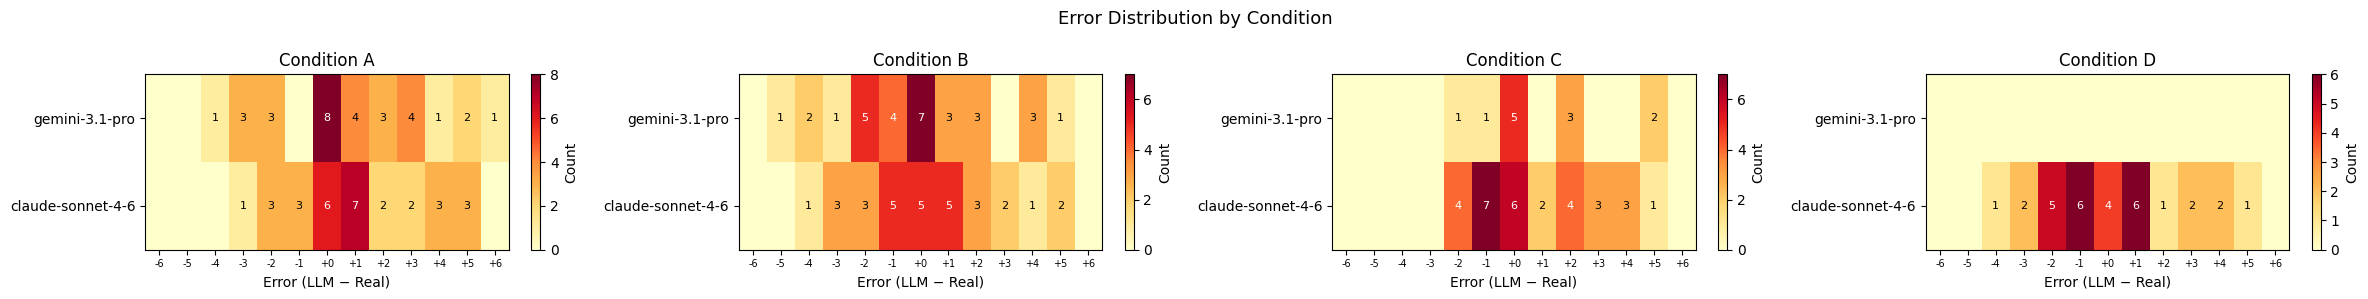

In [16]:
# ── Error distribution heatmap: 4 conditions side by side ──
import matplotlib.pyplot as plt

models_list = df["model"].unique()
error_range = range(-6, 7)

fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(6 * len(CONDITIONS), max(3, len(models_list) * 0.8 + 1)))
if len(CONDITIONS) == 1:
    axes = [axes]

for ax_idx, cond in enumerate(CONDITIONS):
    ax = axes[ax_idx]
    heatmap_data = []
    for model_name in models_list:
        mdf = df[(df["model"] == model_name) & (df["condition"] == cond) & df["error"].notna()]
        err_counts = Counter(mdf["error"].astype(int))
        row = [err_counts.get(e, 0) for e in error_range]
        heatmap_data.append(row)

    heatmap_array = np.array(heatmap_data)
    vmax = max(1, heatmap_array.max())
    im = ax.imshow(heatmap_array, aspect='auto', cmap='YlOrRd', vmin=0, vmax=vmax)
    ax.set_xticks(range(len(list(error_range))))
    ax.set_xticklabels([f"{e:+d}" for e in error_range], fontsize=7)
    ax.set_yticks(range(len(models_list)))
    ax.set_yticklabels(models_list)
    ax.set_xlabel("Error (LLM \u2212 Real)")
    ax.set_title(f"Condition {cond}")

    for i in range(len(models_list)):
        for j in range(len(list(error_range))):
            val = heatmap_array[i, j]
            if val > 0:
                ax.text(j, i, str(val), ha='center', va='center',
                        color='white' if val > vmax * 0.5 else 'black', fontsize=8)

    plt.colorbar(im, ax=ax, label="Count")

plt.suptitle('Error Distribution by Condition', fontsize=13)
plt.tight_layout()
plt.show()

## Response distribution: all conditions vs Ground Truth

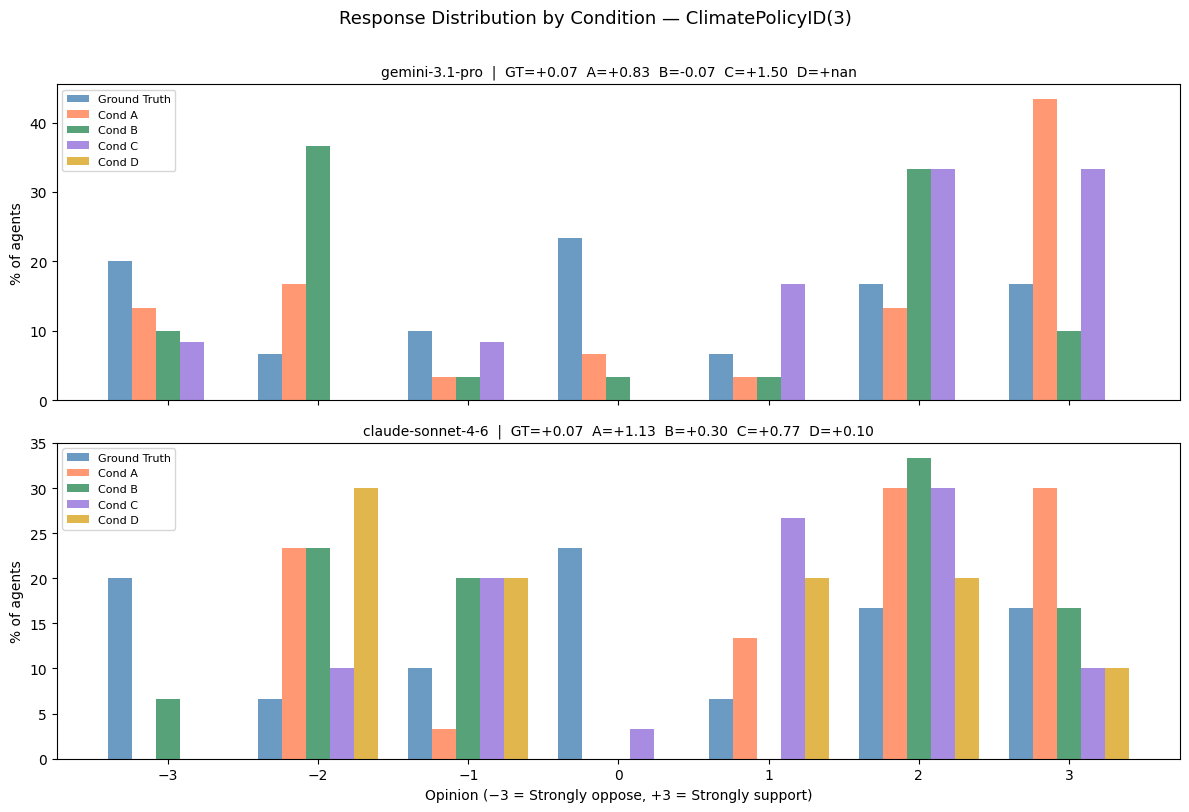

In [17]:
# ── Response distribution per model: all conditions vs Ground Truth ──
scale_values = list(range(-3, 4))
n_models = len(models_list)

fig, axes = plt.subplots(n_models, 1, figsize=(12, 4 * n_models), sharex=True)
if n_models == 1:
    axes = [axes]

# Ground truth distribution
gt_dist = Counter(gt_values)
gt_pcts = [gt_dist.get(v, 0) / len(gt_values) * 100 for v in scale_values]

n_bars = len(CONDITIONS) + 1  # +1 for ground truth
bar_width = 0.8 / n_bars
x = np.array(scale_values)

cond_colors = {"A": "coral", "B": "seagreen", "C": "mediumpurple", "D": "goldenrod"}

for idx, model_name in enumerate(models_list):
    ax = axes[idx]

    # Ground truth bar
    offset = -0.4 + bar_width / 2
    ax.bar(x + offset, gt_pcts, bar_width, label='Ground Truth', color='steelblue', alpha=0.8)

    # Condition bars
    for c_idx, cond in enumerate(CONDITIONS):
        mdf_c = df[(df["model"] == model_name) & (df["condition"] == cond) & df["llm_numeric"].notna()]
        dist_c = Counter(mdf_c["llm_numeric"].astype(int))
        n_c = len(mdf_c)
        pcts_c = [dist_c.get(v, 0) / max(n_c, 1) * 100 for v in scale_values]
        offset = -0.4 + bar_width * (c_idx + 1.5)
        ax.bar(x + offset, pcts_c, bar_width, label=f'Cond {cond}', color=cond_colors[cond], alpha=0.8)

    # Compute means for title
    means_str = ""
    for cond in CONDITIONS:
        mdf_c = df[(df["model"] == model_name) & (df["condition"] == cond) & df["llm_numeric"].notna()]
        m = mdf_c["llm_numeric"].mean() if len(mdf_c) > 0 else float('nan')
        means_str += f"  {cond}={m:+.2f}"

    ax.set_title(f"{model_name}  |  GT={gt_mean:+.2f}{means_str}", fontsize=10)
    ax.set_ylabel('% of agents')
    ax.set_xticks(scale_values)
    ax.legend(loc='upper left', fontsize=8)

axes[-1].set_xlabel('Opinion (\u22123 = Strongly oppose, +3 = Strongly support)')
plt.suptitle(f'Response Distribution by Condition — {POLICY_ID}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Per-agent scatter: all conditions vs Real

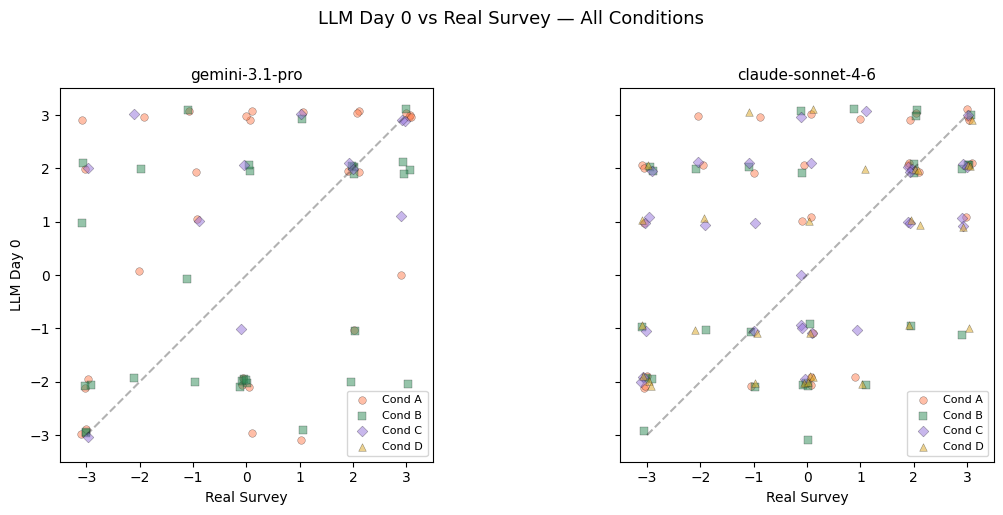

In [18]:
# ── Scatter: LLM vs Real, all conditions ──
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5), sharey=True, sharex=True)
if n_models == 1:
    axes = [axes]

rng = np.random.default_rng(42)

cond_markers = {"A": "o", "B": "s", "C": "D", "D": "^"}

for idx, model_name in enumerate(models_list):
    ax = axes[idx]

    for cond in CONDITIONS:
        mdf = df[(df["model"] == model_name) & (df["condition"] == cond) & df["llm_numeric"].notna()]
        jitter_x = rng.uniform(-0.12, 0.12, size=len(mdf))
        jitter_y = rng.uniform(-0.12, 0.12, size=len(mdf))
        ax.scatter(
            mdf["real_numeric"] + jitter_x, mdf["llm_numeric"] + jitter_y,
            alpha=0.5, s=30, edgecolors='black', linewidths=0.3,
            color=cond_colors[cond], marker=cond_markers[cond], label=f'Cond {cond}',
        )

    ax.plot([-3, 3], [-3, 3], 'k--', alpha=0.3)
    ax.set_title(model_name, fontsize=11)
    ax.set_xlabel('Real Survey')
    if idx == 0:
        ax.set_ylabel('LLM Day 0')
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_xticks(range(-3, 4))
    ax.set_yticks(range(-3, 4))
    ax.set_aspect('equal')
    ax.legend(fontsize=8)

plt.suptitle('LLM Day 0 vs Real Survey — All Conditions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Scale reversal analysis (Conditions C & D)

Check whether agents with reversed scale order respond differently, which would indicate
a positional bias (primacy/recency effect) in scale selection.

In [19]:
# ── Scale reversal analysis ──
print("Scale Reversal Effect (Conditions C & D)")
print("=" * 70)
print(f"{'Model':<22} {'Cond':>5} {'Normal Mean':>12} {'Reversed Mean':>14} {'\u0394':>6} {'Normal MAE':>11} {'Reversed MAE':>13}")
print("-" * 90)

for model_name in summary["Model"].unique():
    for cond in ["C", "D"]:
        mdf = df[(df["model"] == model_name) & (df["condition"] == cond) & df["llm_numeric"].notna()].copy()
        if len(mdf) == 0:
            continue

        normal = mdf[mdf["reversed_scale"] == False]
        reversed_ = mdf[mdf["reversed_scale"] == True]

        if len(normal) == 0 or len(reversed_) == 0:
            continue

        nm = normal["llm_numeric"].mean()
        rm = reversed_["llm_numeric"].mean()
        n_mae = normal["abs_error"].mean()
        r_mae = reversed_["abs_error"].mean()

        print(f"{model_name:<22} {cond:>5} {nm:>+11.2f}  {rm:>+13.2f}  {rm-nm:>+5.2f}  {n_mae:>10.2f}  {r_mae:>12.2f}")

print()
print("\u0394 > 0 \u2192 reversed scale produces more positive (pro-climate) responses")
print("\u0394 < 0 \u2192 reversed scale produces more negative (anti-climate) responses")
print("Large |\u0394| \u2192 strong positional bias in scale selection")

Scale Reversal Effect (Conditions C & D)
Model                   Cond  Normal Mean  Reversed Mean      Δ  Normal MAE  Reversed MAE
------------------------------------------------------------------------------------------
claude-sonnet-4-6          C       +1.20          +0.33  -0.87        2.20          1.20
claude-sonnet-4-6          D       +0.13          +0.07  -0.07        2.07          1.47
gemini-3.1-pro             C       +1.57          +1.40  -0.17        2.71          0.00

Δ > 0 → reversed scale produces more positive (pro-climate) responses
Δ < 0 → reversed scale produces more negative (anti-climate) responses
Large |Δ| → strong positional bias in scale selection


## Sample reasoning (Conditions B & D)

In [20]:
# ── Show sample step-1 reasoning from conditions B and D ──
print("Sample Step-1 Reasoning")
print("=" * 70)

for model_name in summary["Model"].unique():
    for cond in ["B", "D"]:
        mdf = df[(df["model"] == model_name) & (df["condition"] == cond)
                 & df["step1_reasoning"].notna()].head(3)
        if len(mdf) == 0:
            continue

        print(f"\n--- {model_name} — Condition {cond} ---")
        for _, row in mdf.iterrows():
            real = row["real_numeric"]
            llm = row["llm_numeric"]
            err = row["error"]
            reasoning = row["step1_reasoning"]
            print(f"\nAgent {row['agent_id']} (real={real:+d}, llm={llm:+.0f}, err={err:+.0f}):")
            print(f"  {reasoning[:300]}{'...' if len(str(reasoning)) > 300 else ''}")

Sample Step-1 Reasoning

--- claude-sonnet-4-6 — Condition B ---

Agent 1729.0 (real=+1, llm=+3, err=+2):
  This person's strong environmental commitment, Green Party voting history, and deep belief in protecting nature would likely make her a firm supporter of this policy, as phasing out petrol cars aligns directly with her core values around ecological preservation and climate action. However, her relat...

Agent 1293.0 (real=-3, llm=-3, err=+0):
  **Likely position: Oppose (moderately to strongly)**

Her right-wing Conservative and Leave-voting background strongly predisposes her against top-down government mandates on personal consumer choices, and the 2030 deadline would feel rushed and impractical — particularly as someone in the East of E...

Agent 509.0 (real=-2, llm=+2, err=+4):
  This person's strong environmental values and Green Party voting history would push her toward supporting this policy, as it aligns directly with her deep commitment to nature protection and tackling

## Save results

In [21]:
# ── Save ──
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = f"../data/output/experiments/{timestamp}_mitigation_experiment"
os.makedirs(out_dir, exist_ok=True)

df.to_csv(f"{out_dir}/per_agent_results.csv", index=False)
summary.to_csv(f"{out_dir}/model_summary.csv", index=False)

# Save config
config = {
    "experiment": "13_bias_mitigation",
    "conditions": {
        "A": "control (single-step, A-G letter scale)",
        "B": "two-step reasoning + anti-sycophancy, A-G letter scale",
        "C": "single-step, numeric -3 to +3 (50% reversed)",
        "D": "two-step reasoning + anti-sycophancy, numeric -3 to +3 (50% reversed)",
    },
    "models": [name for name, _, _ in MODELS],
    "n_agents": N_AGENTS,
    "random_seed": RANDOM_SEED,
    "temperature": TEMPERATURE,
    "thinking": THINKING,
    "policy": str(POLICY_ID),
    "ground_truth_mean": gt_mean,
}
with open(f"{out_dir}/config.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"Results saved to {out_dir}/")
print()
print(summary[display_cols].to_string(index=False))

Results saved to ../data/output/experiments/20260419_002808_mitigation_experiment/

            Model Condition  n  Mean LLM  Exact %  Ordinal  Mean Error      MAE  Direction %  Spearman ρ
claude-sonnet-4-6         A 30  1.133333 0.200000 0.688889    1.066667 1.866667     0.500000    0.416953
claude-sonnet-4-6         B 30  0.300000 0.166667 0.694444    0.233333 1.833333     0.533333    0.424264
claude-sonnet-4-6         C 30  0.766667 0.200000 0.716667    0.700000 1.700000     0.533333    0.391968
claude-sonnet-4-6         D 30  0.100000 0.133333 0.705556    0.033333 1.766667     0.533333    0.384762
   gemini-3.1-pro         A 30  0.833333 0.266667 0.661111    0.766667 2.033333     0.433333    0.376492
   gemini-3.1-pro         B 30 -0.066667 0.233333 0.688889   -0.133333 1.866667     0.466667    0.377005
   gemini-3.1-pro         C 12  1.500000 0.416667 0.736111    1.083333 1.583333     0.583333    0.367769


## Notes

**What to look for:**

1. **\u0394 Mean Error < 0** — Treatment reduces pro-climate bias (moves mean error closer to 0)
2. **\u0394 MAE < 0** — Treatment improves absolute accuracy
3. **\u0394 Spearman > 0** — Treatment preserves or improves ranking of agents
4. **Wilcoxon p < 0.05** — The MAE difference is statistically significant (paired test)
5. **Response distribution** — Treatments use more of the negative end of the scale
6. **Scale reversal \u0394** — Large effect = positional bias exists (supports intervention C)
7. **Reasoning quality** — Step 1 reasoning mentions opposing factors (confirms the mechanism)

**Key design decisions:**
- Same 30 agents + seed 44 as notebooks 11-12 for comparability
- `send_chat()` called directly to inject custom prompts without modifying source code
- Conditions B and D use 2 LLM calls: step 1 (reasoning) is fed back as system context for step 2
- Anti-sycophancy instruction explicitly mentions "strong opposition" to permit anti-climate responses
- Scale randomisation is deterministic (agent\_index % 2) so reversed/normal groups are balanced
- `parse_numeric_response()` mirrors the 3-tier extraction logic of `parse_letter_response()`